data based on running 

`python Calibration.py ../../configs/unbinned/unbinned_2016.yaml --job bit_pod_TTLep_pow_2016 --write_pandas`

with the `--write_pandas` added by me to write out csv file to disk.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

In [2]:
df1 = pd.read_csv("delphes/calib_prediction_valid1.csv", index_col=0)
df2 = pd.read_csv("delphes/calib_prediction_valid2.csv", index_col=0)

data = pd.concat([df1, df2], axis=0)  # 按行拼接
total_weight = data.iloc[:, -1].sum()
print(total_weight)

264.35413078658803


In [3]:
data.head(10)

,c0_truth,c0_pred,c1_truth,c1_pred,c2_truth,c2_pred,c3_truth,c3_pred,c4_truth,c4_pred,...,c3 * c4_pred,c3 * c5_truth,c3 * c5_pred,c4^2_truth,c4^2_pred,c4 * c5_truth,c4 * c5_pred,c5^2_truth,c5^2_pred,weight
0,-0.046061,-0.139712,-0.002937,0.067017,-0.058573,-0.006110,0.100813,0.093699,-0.102451,-0.156977,...,-0.010092,-0.001414,-0.005846,-0.000731,0.002310,0.000514,0.006131,0.000383,0.004917,0.000264
1,-0.407310,-0.173099,0.401839,0.088365,0.428626,0.002200,-0.259553,0.097953,-0.063446,-0.144559,...,-0.009984,-0.007780,-0.004469,0.000046,0.003520,0.002238,0.004262,0.017051,0.003029,0.000264
2,-0.582656,-0.344207,0.542733,0.248286,0.535769,0.150038,-0.304990,0.036057,0.012545,-0.158983,...,-0.009686,-0.031820,-0.009421,-0.005810,0.007879,0.010210,0.003666,-0.002629,0.000960,0.000264
3,-0.038916,-0.129687,-0.098840,0.036662,-0.251897,-0.062925,0.318077,0.158808,-0.268125,-0.204996,...,-0.015540,-0.012767,-0.008592,-0.010142,0.001660,0.010043,0.006844,0.003565,0.005275,0.000264
4,-0.020917,-0.124579,-0.027911,-0.020404,-0.080122,-0.174343,0.094561,0.245347,-0.052330,-0.143910,...,-0.016996,-0.000695,0.000364,0.001279,0.009729,0.000177,0.000137,-0.000094,-0.000099,0.000264
5,-0.355843,-0.287572,0.252378,0.236468,0.145054,0.200079,0.064261,-0.081680,-0.245835,-0.024767,...,0.004279,-0.021352,-0.000266,0.013158,-0.002528,0.008181,0.000951,0.004487,0.001737,0.000264
6,-0.339120,-0.408611,0.148022,0.272040,-0.077115,0.117814,0.320000,0.120919,-0.340907,-0.198601,...,-0.014812,-0.009642,-0.002092,0.044903,0.020480,0.003077,0.001819,-0.001776,-0.000347,0.000264
7,-0.384658,-0.115680,0.204707,-0.034550,-0.007999,-0.194543,0.278609,0.263060,-0.362755,-0.154372,...,-0.019593,-0.017414,-0.000114,0.047037,0.010584,0.006253,0.000321,-0.002920,0.000117,0.000264
8,-0.166743,-0.099656,-0.009787,-0.044996,-0.205367,-0.198152,0.321249,0.258074,-0.227085,-0.152733,...,-0.019086,-0.001640,-0.001091,0.013523,0.009244,0.000105,0.000888,-0.000071,0.000149,0.000264
9,-0.202926,-0.169786,0.012636,0.050697,-0.200494,-0.077098,0.335429,0.185935,-0.223147,-0.187795,...,-0.017490,0.002782,-0.005762,0.023931,0.006644,-0.001967,0.003842,0.000112,0.002043,0.000264


In [4]:
label = []
truth_list = []
pred_list = []

for elem in data:
    tmp_label = elem.split('_')[0]
    if tmp_label in label:
        pass
    else:
        label.append(tmp_label)
    if "_truth" in elem:
        truth_list.append(data[elem].to_numpy())
    elif "_pred" in elem:
        pred_list.append(data[elem].to_numpy())
    elif "weight" in elem:
        weights = data[elem].to_numpy()
    else:
        print("???")

truth_list = np.array(truth_list)
pred_list = np.array(pred_list)
        
print(len(label), label)
print(truth_list.shape)
print(pred_list.shape)
print(weights.shape)


28 ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c0^2', 'c0 * c1', 'c0 * c2', 'c0 * c3', 'c0 * c4', 'c0 * c5', 'c1^2', 'c1 * c2', 'c1 * c3', 'c1 * c4', 'c1 * c5', 'c2^2', 'c2 * c3', 'c2 * c4', 'c2 * c5', 'c3^2', 'c3 * c4', 'c3 * c5', 'c4^2', 'c4 * c5', 'c5^2', 'weight']
(27, 1008914)
(27, 1008914)
(1008914,)


In [5]:
def weighted_mean(array, weight):
    return (array*weight).sum() / weight.sum() 
def weighted_std(array, weight):
    #var = weighted_mean(array**2, weight) - weighted_mean(array, weight)**2
    mean = weighted_mean(array, weight)
    var = weighted_mean((array-mean)**2, weight)
    return np.sqrt(np.abs(var))

def unweighted_std(array, weight=None):
    mean = np.mean(array)
    var = np.mean((array - mean)**2)
    return np.sqrt(var)


Top panel uncertainties (weighted count errors) for c0:
bin_idx    left_edge         right_edge        center           count            uncertainty
  0    -0.96999894    -0.92984060    -0.94991977     5.27309836e-04     3.72864361e-04
  1    -0.92984060    -0.88968227    -0.90976144     5.27309836e-04     3.72864361e-04
  2    -0.88968227    -0.84952393    -0.86960310     7.90964754e-04     4.56663714e-04
  3    -0.84952393    -0.80936559    -0.82944476     3.69116885e-03     1.05461967e-03
  4    -0.80936559    -0.76920725    -0.78928642     7.90964754e-03     1.44409746e-03
  5    -0.76920725    -0.72904891    -0.74912808     1.39737107e-02     2.05921074e-03
  6    -0.72904891    -0.68889057    -0.70896974     3.32205197e-02     3.14181095e-03
  7    -0.68889057    -0.64873224    -0.66881141     5.95860115e-02     4.10150797e-03
  8    -0.64873224    -0.60857390    -0.62865307     1.45537515e-01     6.43663684e-03
  9    -0.60857390    -0.56841556    -0.58849473     3.12167423e-01

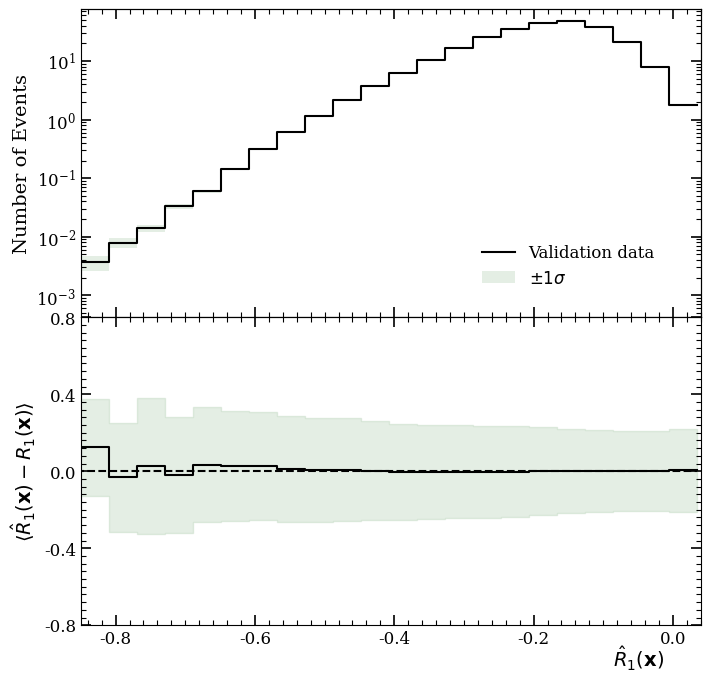

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
})
num_bins = 25

def counts_to_RunII(counts):
    return counts * (24.12 * 137. / 16.81)

idx = label.index('c0')
lab = 'c0'

bins = np.linspace(pred_list[idx].min(), pred_list[idx].max(), num_bins + 1)
bin_centers = 0.5 * (bins[1:] + bins[:-1])

which_bin = (pred_list[idx] > bins[:-1].reshape(-1, 1)) & (pred_list[idx] <= bins[1:].reshape(-1, 1))

tmp_truth, tmp_pred = [], []
tmp_std1, tmp_std2 = [], []
tmp_count = []
tmp_count_err = []
tmp_bin_left = []
tmp_bin_right = []
tmp_bin_center = []

for i in range(num_bins):
    if not np.any(which_bin[i]):
        continue

    y_bin = truth_list[idx][which_bin[i]]
    y_pred_bin = pred_list[idx][which_bin[i]]
    w_bin = weights[which_bin[i]]
    
    res_bin = y_bin - y_pred_bin
    
    mean_w = weighted_mean(res_bin, w_bin)
    std_w  = weighted_std(res_bin, w_bin)

    Neff = (w_bin.sum() ** 2) / ((w_bin ** 2).sum() + 1e-12)
    se_wmean = std_w / np.sqrt(max(Neff, 1e-12))

    tmp_truth += [mean_w, mean_w]
    tmp_std1 += [std_w, std_w]
    tmp_std2 += [se_wmean, se_wmean]
    tmp_pred += [bins[i], bins[i + 1]]

    count = w_bin.sum()
    count_err = np.sqrt(np.sum(w_bin**2))
    
    tmp_count += [count, count]
    tmp_count_err += [count_err, count_err]

    tmp_bin_left.append(bins[i])
    tmp_bin_right.append(bins[i + 1])
    tmp_bin_center.append(0.5 * (bins[i] + bins[i + 1]))

tmp_truth = np.array(tmp_truth)
tmp_pred = np.array(tmp_pred)
tmp_std1 = np.array(tmp_std1)
tmp_std2 = np.array(tmp_std2)
tmp_count = np.array(tmp_count)
tmp_count_err = np.array(tmp_count_err)

tmp_bin_left = np.array(tmp_bin_left)
tmp_bin_right = np.array(tmp_bin_right)
tmp_bin_center = np.array(tmp_bin_center)

count_err_per_bin = tmp_count_err[::2]
count_per_bin = tmp_count[::2]

print("\nTop panel uncertainties (weighted count errors) for c0:")
print("bin_idx    left_edge         right_edge        center           count            uncertainty")
for i, (bl, br, bc, c, ce) in enumerate(zip(tmp_bin_left, tmp_bin_right, tmp_bin_center, count_per_bin, count_err_per_bin)):
    print(f"{i:3d}    {bl: .8f}    {br: .8f}    {bc: .8f}    {c: .8e}    {ce: .8e}")

label_fontsize = 14
tick_label_size = 12

fig, (ax_bottom, ax_top) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(8, 8),
    gridspec_kw={'hspace': 0.0, 'height_ratios': [1, 1]}
)

ax_bottom.set_yscale('log')
ax_bottom.set_ylabel('Number of Events', fontsize=label_fontsize)

positive_counts = tmp_count[tmp_count > 0]
ax_bottom.set_ylim(
    max(np.min(positive_counts) * 0.8, 1e-4),
    np.max(positive_counts) * 1.6
)

ax_bottom.tick_params(axis='y', which='both', left=True, right=False, labelright=False)

ax_bottom_right = ax_bottom.twinx()
ax_bottom_right.set_yscale('log')

ax_bottom_right.set_ylim(ax_bottom.get_ylim())
ax_bottom_right.yaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax_bottom_right.yaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
)
ax_bottom_right.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
ax_bottom_right.yaxis.set_minor_formatter(mticker.NullFormatter())

ax_bottom_right.yaxis.set_ticks_position('right')
ax_bottom_right.spines['left'].set_visible(False)

ax_bottom_right.tick_params(
    axis='y',
    which='major',
    right=True,
    left=False,
    labelright=False,
    labelleft=False,
    direction='in',
    length=7.2,
    width=1.2
)

ax_bottom_right.tick_params(
    axis='y',
    which='minor',
    right=True,
    left=False,
    labelright=False,
    labelleft=False,
    direction='in',
    length=3.6,
    width=0.8
)

ax_top.plot(tmp_pred, tmp_truth, color='k', label=r'$\langle \hat{R}_1(\mathbf{x}) - R_1(\mathbf{x}) \rangle$')
ax_top.fill_between(
    tmp_pred,
    tmp_truth + tmp_std1,
    tmp_truth - tmp_std1,
    color='#a6c8a6',
    alpha=0.3,
    label=r'$\pm 1 \sigma$'
)
ax_top.plot(
    [tmp_pred.min(), tmp_pred.max()],
    [0., 0.],
    linestyle='--',
    color='k'
)
ax_top.set_ylabel(
    r'$\langle \hat{R}_1(\mathbf{x}) - R_1(\mathbf{x}) \rangle$',
    fontsize=label_fontsize
)
ax_top.set_xlabel(r'$\hat{R}_1(\mathbf{x})$', fontsize=label_fontsize)
ax_top.xaxis.set_label_coords(0.9, -0.06)

ax_top.set_ylim(-0.8, 0.8)

major_ticks = np.array([-1.0, -0.8, -0.6, -0.4, -0.2, 0.0])

for ax in [ax_top, ax_bottom]:
    ax.xaxis.set_major_locator(mticker.FixedLocator(major_ticks))
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.02))

    ax.tick_params(axis='x', which='both', direction='in', top=True)
    ax.tick_params(axis='x', which='major', length=7.2, width=1.2)
    ax.tick_params(axis='x', which='minor', length=3.6, width=0.8)
    ax.tick_params(axis='both', labelsize=tick_label_size)

ax_bottom.tick_params(axis='x', which='both', labelbottom=False)

ax_bottom.yaxis.set_major_locator(mticker.LogLocator(base=10.0))
ax_bottom.yaxis.set_minor_locator(
    mticker.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1)
)
ax_bottom.yaxis.set_minor_formatter(mticker.NullFormatter())

ax_bottom.tick_params(axis='y', which='major', length=7.2, width=1.2, direction='in')
ax_bottom.tick_params(axis='y', which='minor', length=3.6, width=0.8, direction='in')
count_lower = np.clip(tmp_count - tmp_count_err, 1e-12, None)
count_upper = tmp_count + tmp_count_err

unc_band = ax_bottom.fill_between(
    tmp_pred,
    count_lower,
    count_upper,
    step='post',
    color='#a6c8a6',
    alpha=0.3,
    linewidth=0,
    label=r'$\pm 1\sigma$'
)

val_line = ax_bottom.step(
    tmp_pred,
    tmp_count,
    where='post',
    color='k',
    label='Validation data'
)

handles = [val_line[0], unc_band]
labels_legend = ['Validation data', r'$\pm 1\sigma$']
ax_bottom.legend(
    handles,
    labels_legend,
    frameon=False,
    fontsize=12,
    loc='lower right',
    bbox_to_anchor=(0.95, 0.05)
)

y_major = np.array([-0.8, -0.4, 0.0, 0.4, 0.8])
ax_top.yaxis.set_major_locator(mticker.FixedLocator(y_major))
ax_top.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
ax_top.yaxis.set_minor_locator(mticker.MultipleLocator(0.04))
ax_top.yaxis.set_minor_formatter(mticker.NullFormatter())

ax_top.tick_params(axis='y', which='both', left=True, right=True, labelleft=True, labelright=False)
ax_top.tick_params(axis='y', which='major', length=7.2, width=1.2, direction='in')
ax_top.tick_params(axis='y', which='minor', length=3.6, width=0.8, direction='in')

ax_top.set_xlim(-0.85, 0.04)
plt.subplots_adjust(hspace=0.0)
plt.savefig("c0.pdf", bbox_inches='tight', dpi=1000)
plt.show()